In [1]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.84.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp313-cp313-win_amd64.whl.metadata (8.8 kB)
  Using cach

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [2]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    multilabel_confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (159571, 8)


In [5]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate comments:", df["comment_text"].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate comments: 0


In [9]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

print("Target columns:")
for col in label_columns:
    print(col)

Target columns:
toxic
severe_toxic
obscene
threat
insult
identity_hate


In [10]:
label_counts = df[label_columns].sum().sort_values(ascending=False)

print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


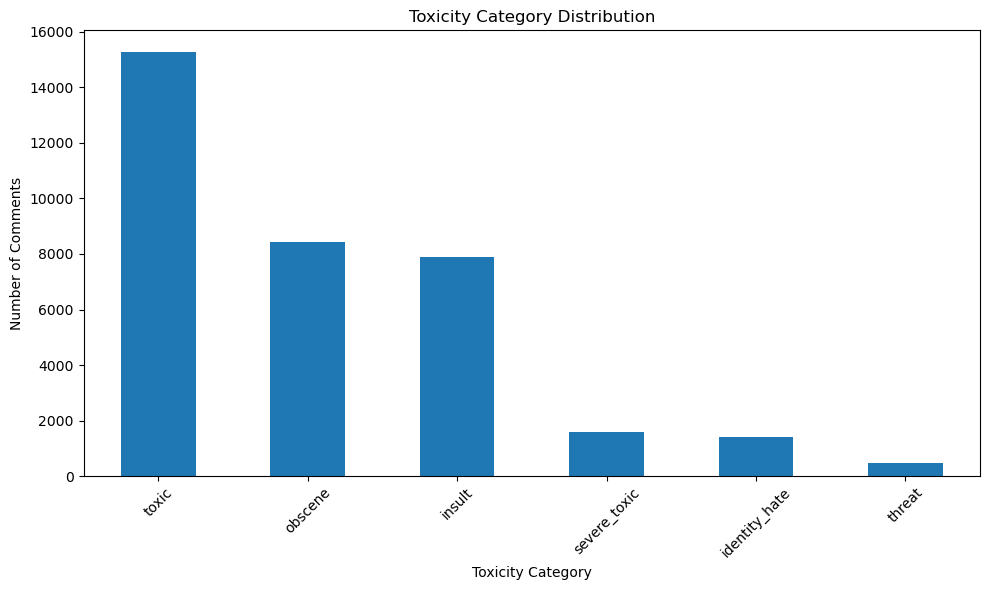

In [11]:
plt.figure(figsize=(10, 6))

label_counts.plot(kind="bar")

plt.title("Toxicity Category Distribution")
plt.xlabel("Toxicity Category")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
label_percentage = (
    df[label_columns].mean() * 100
).sort_values(ascending=False)

print(label_percentage.round(2))

toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64


In [13]:
df["any_toxic"] = df[label_columns].max(axis=1)

print(
    "Non-toxic comments:",
    (df["any_toxic"] == 0).sum()
)

print(
    "Comments with at least one toxic category:",
    (df["any_toxic"] == 1).sum()
)

Non-toxic comments: 143346
Comments with at least one toxic category: 16225


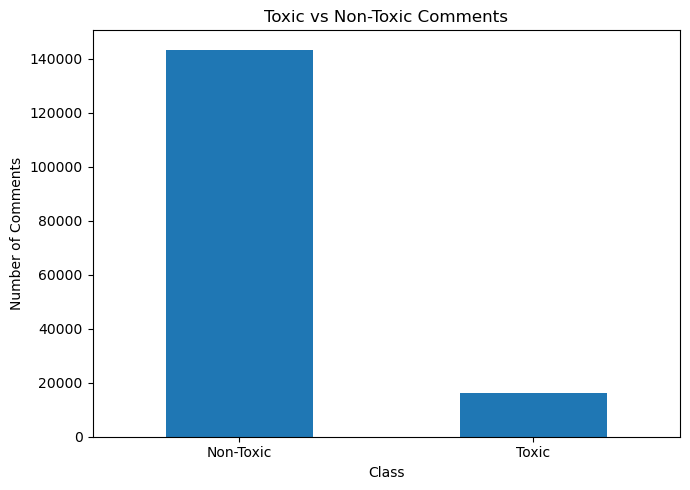

In [14]:
plt.figure(figsize=(7, 5))

df["any_toxic"].value_counts().plot(kind="bar")

plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Class")
plt.ylabel("Number of Comments")
plt.xticks(
    [0, 1],
    ["Non-Toxic", "Toxic"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [15]:
df["comment_length"] = df["comment_text"].astype(str).apply(len)

print(df["comment_length"].describe())

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64


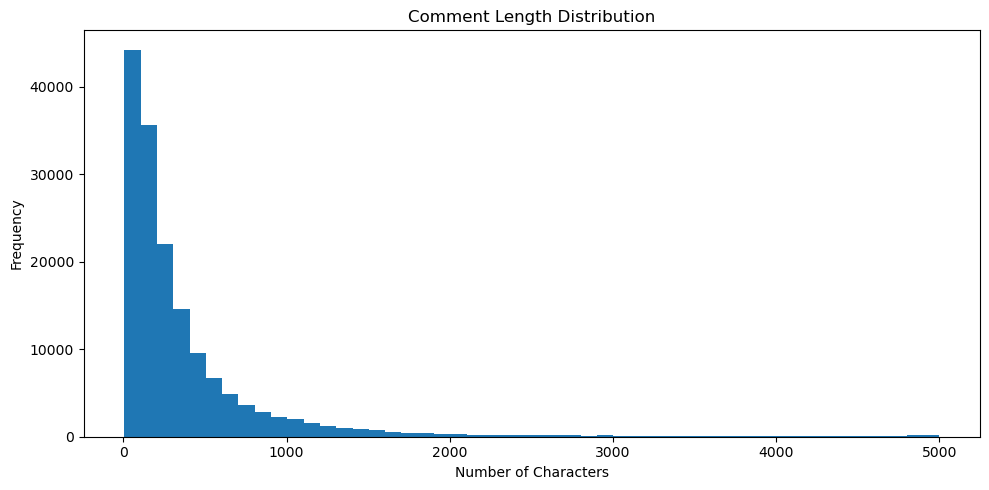

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title("Comment Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
def clean_text(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Keep letters, numbers and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [18]:
sample_text = df["comment_text"].iloc[0]

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text(sample_text))

Original:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Cleaned:
explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now 89 205 38 27


In [19]:
df["clean_comment"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i m se...
2,"Hey man, I'm really not trying to edit war. It...",hey man i m really not trying to edit war it s...
3,"""\nMore\nI can't make any real suggestions on ...",more i can t make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


In [20]:
df = df[df["clean_comment"].str.len() > 0].copy()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (159557, 11)


In [21]:
X = df["clean_comment"].values
y = df[label_columns].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (159557,)
y shape: (159557, 6)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 127645
Testing samples: 31912


In [23]:
MAX_WORDS = 30000
MAX_LEN = 150

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 152045


In [24]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("First training sequence:")
print(X_train_sequences[0])

First training sequence:
[29, 4, 75, 764, 6, 21, 2522]


In [25]:
X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

X_train shape: (127645, 150)
X_test shape: (31912, 150)


In [27]:
model = Sequential([
    
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),
    
    Bidirectional(
        LSTM(64, return_sequences=False)
    ),
    
    Dropout(0.5),
    
    Dense(
        64,
        activation="relu"
    ),
    
    Dropout(0.3),
    
    Dense(
        len(label_columns),
        activation="sigmoid"
    )
])

# Build the model explicitly
model.build(input_shape=(None, MAX_LEN))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,462 (15.06 MB)

 Trainable params: 3,947,462 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [30]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

print("Early stopping is ready!")

Early stopping is ready!


In [31]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.10,
    epochs=5,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 431s 473ms/step - accuracy: 0.8494 - loss: 0.0854 - val_accuracy: 0.9936 - val_loss: 0.0512
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 464s 517ms/step - accuracy: 0.9787 - loss: 0.0488 - val_accuracy: 0.9936 - val_loss: 0.0481
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 502s 559ms/step - accuracy: 0.9894 - loss: 0.0428 - val_accuracy: 0.9936 - val_loss: 0.0496
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 489s 544ms/step - accuracy: 0.9836 - loss: 0.0385 - val_accuracy: 0.9936 - val_loss: 0.0512


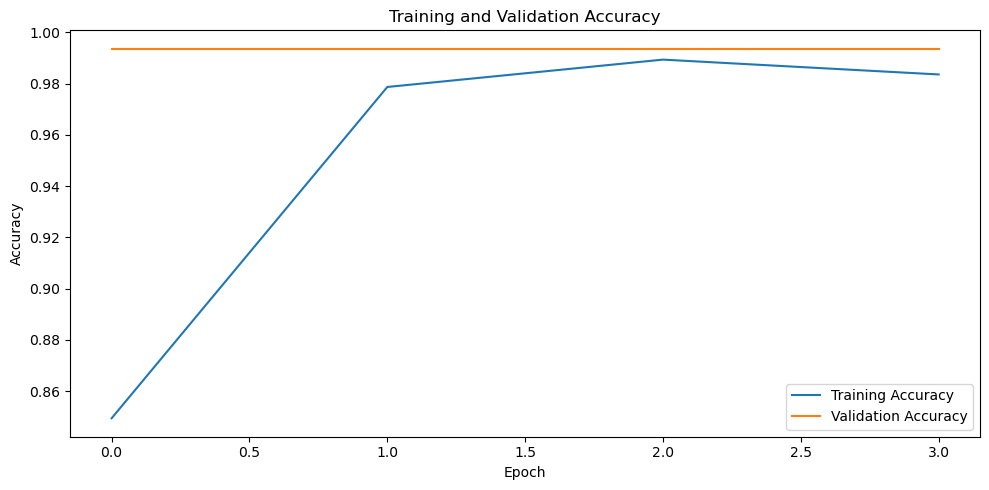

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

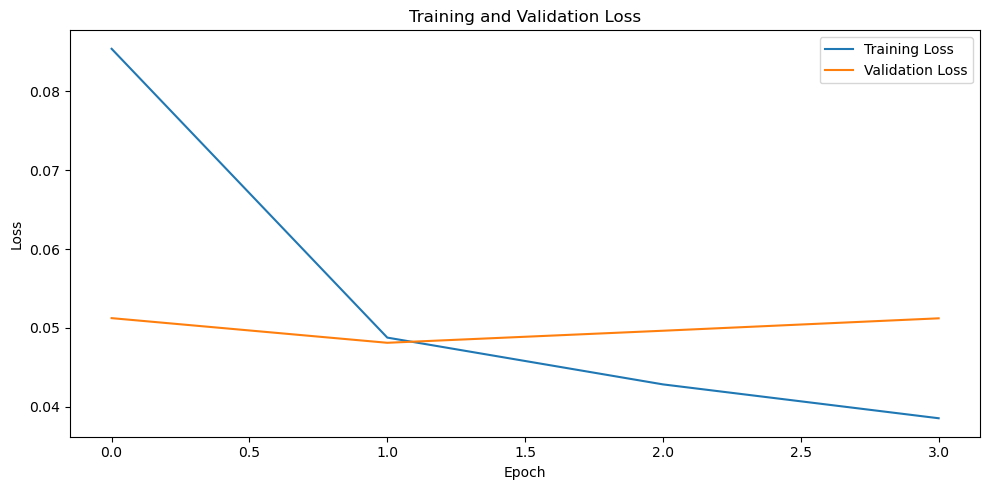

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

998/998 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.9939 - loss: 0.0483
Test Loss: 0.048303619027137756
Test Accuracy: 0.9938894510269165


In [35]:
y_pred_probability = model.predict(
    X_test_pad,
    batch_size=256
)

print(y_pred_probability.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 269ms/step
(31912, 6)


In [36]:
threshold = 0.5

y_pred = (
    y_pred_probability >= threshold
).astype(int)

print(y_pred[:5])

[[0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [37]:
for i, label in enumerate(label_columns):
    
    print("\n" + "=" * 60)
    print(label.upper())
    print("=" * 60)
    
    print(
        classification_report(
            y_test[:, i],
            y_pred[:, i],
            zero_division=0
        )
    )


TOXIC
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28846
           1       0.84      0.76      0.80      3066

    accuracy                           0.96     31912
   macro avg       0.91      0.87      0.89     31912
weighted avg       0.96      0.96      0.96     31912


SEVERE_TOXIC
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31591
           1       0.58      0.19      0.28       321

    accuracy                           0.99     31912
   macro avg       0.78      0.59      0.64     31912
weighted avg       0.99      0.99      0.99     31912


OBSCENE
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     30209
           1       0.82      0.78      0.80      1703

    accuracy                           0.98     31912
   macro avg       0.91      0.88      0.90     31912
weighted avg       0.98      0.98      0.98 

In [38]:
precision = precision_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9196
Precision: 0.8012
Recall   : 0.6821
F1 Score : 0.7369


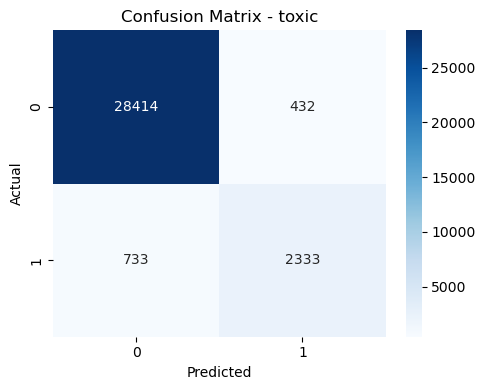

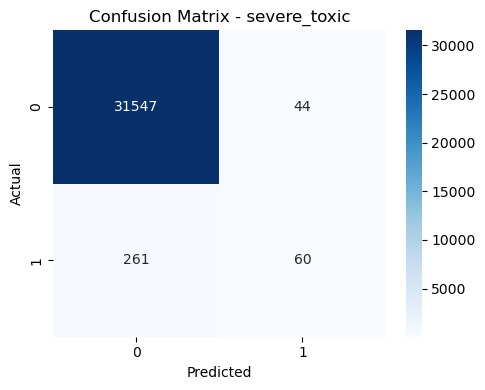

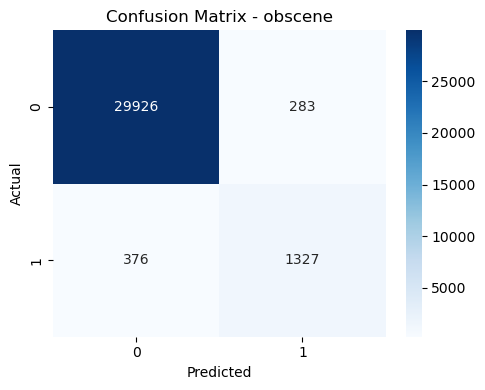

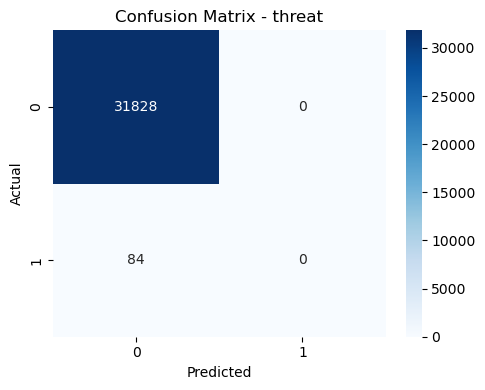

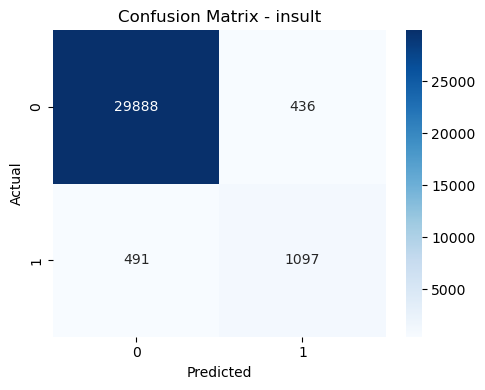

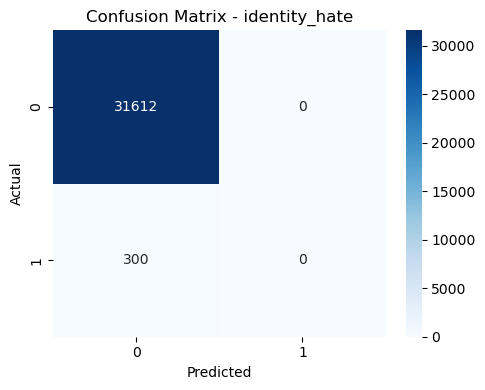

In [39]:
conf_matrices = multilabel_confusion_matrix(
    y_test,
    y_pred
)

for i, label in enumerate(label_columns):
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        conf_matrices[i],
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

In [40]:
def predict_comment(comment):
    
    cleaned = clean_text(comment)
    
    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )
    
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )
    
    prediction = model.predict(
        padded,
        verbose=0
    )[0]
    
    result = {}
    
    for label, probability in zip(
        label_columns,
        prediction
    ):
        result[label] = float(probability)
    
    return result

In [41]:
comment = "You are a wonderful person."

result = predict_comment(comment)

result

{'toxic': 0.14254805445671082,
 'severe_toxic': 0.0015459924470633268,
 'obscene': 0.027237746864557266,
 'threat': 0.003891934175044298,
 'insult': 0.035815514624118805,
 'identity_hate': 0.010283725336194038}

In [42]:
comment = "I hate you and you are stupid."

result = predict_comment(comment)

result

{'toxic': 0.9805721044540405,
 'severe_toxic': 0.13424250483512878,
 'obscene': 0.8539115190505981,
 'threat': 0.05248456075787544,
 'insult': 0.7195956707000732,
 'identity_hate': 0.15368106961250305}

In [43]:
os.makedirs("model", exist_ok=True)

print("Model folder created!")

Model folder created!


In [44]:
model.save(
    "model/toxicity_model.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [45]:
with open(
    "model/tokenizer.pkl",
    "wb"
) as file:
    
    pickle.dump(
        tokenizer,
        file
    )

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [46]:
config = {
    "max_words": MAX_WORDS,
    "max_len": MAX_LEN,
    "threshold": threshold,
    "labels": label_columns
}

with open(
    "model/config.pkl",
    "wb"
) as file:
    
    pickle.dump(
        config,
        file
    )

print("Configuration saved successfully!")

Configuration saved successfully!


In [47]:
# Cell 44 - Load Original Test CSV

test_df = pd.read_csv("test.csv")

print("Test file loaded successfully!")
print("Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())

Test file loaded successfully!
Shape: (153164, 2)

Columns:
['id', 'comment_text']

First 5 rows:


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [48]:


test_df = pd.read_csv("test.csv")

print("Test file loaded successfully!")
print("Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())

Test file loaded successfully!
Shape: (153164, 2)

Columns:
['id', 'comment_text']

First 5 rows:


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [49]:


print("Test data shape:", test_df.shape)

print("\nMissing values:")
print(test_df.isnull().sum())

print("\nDuplicate IDs:")
print(test_df["id"].duplicated().sum())

print("\nFirst 5 comments:")
display(test_df.head())

Test data shape: (153164, 2)

Missing values:
id              0
comment_text    0
dtype: int64

Duplicate IDs:
0

First 5 comments:


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [50]:
#Clean Test Comments

test_df["cleaned_comment"] = test_df["comment_text"].fillna("").apply(clean_text)

print("Test comments cleaned successfully!")

display(test_df[["comment_text", "cleaned_comment"]].head())

Test comments cleaned successfully!


,comment_text,cleaned_comment
0,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule is more succesful then you ll...
1,== From RfC == \n\n The title is fine as it is...,from rfc the title is fine as it is imo
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton on lapland
3,":If you have a look back at the source, the in...",if you have a look back at the source the info...
4,I don't anonymously edit articles at all.,i don t anonymously edit articles at all


In [51]:
# Tokenize Test Comments

test_sequences = tokenizer.texts_to_sequences(
    test_df["cleaned_comment"]
)

test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Test sequences created successfully!")
print("Shape:", test_padded.shape)

Test sequences created successfully!
Shape: (153164, 150)


In [52]:
# Predict Test Comments

test_predictions_probability = model.predict(
    test_padded,
    batch_size=256,
    verbose=1
)

print("Predictions completed!")
print("Prediction shape:", test_predictions_probability.shape)

599/599 ━━━━━━━━━━━━━━━━━━━━ 185s 308ms/step
Predictions completed!
Prediction shape: (153164, 6)


In [53]:
#  Convert Predictions

test_predictions = (
    test_predictions_probability >= threshold
).astype(int)

print("Binary predictions created successfully!")
print("Shape:", test_predictions.shape)

Binary predictions created successfully!
Shape: (153164, 6)


In [54]:
#  Create Final Prediction DataFrame

prediction_df = test_df[["id", "comment_text"]].copy()

for i, label in enumerate(label_columns):
    prediction_df[label] = test_predictions[:, i]

print("Prediction DataFrame created successfully!")

display(prediction_df.head())

Prediction DataFrame created successfully!


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,1,0,1,0,1,0
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,0,0,0,0,0,0
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",0,0,0,0,0,0
3,00017563c3f7919a,":If you have a look back at the source, the in...",0,0,0,0,0,0
4,00017695ad8997eb,I don't anonymously edit articles at all.,0,0,0,0,0,0


In [55]:
# Save Final Predictions

output_file = "C:\\Users\\ABHISHEK\\Documents\\Data Science\\CommentToxicity_Project\\test_predictions.csv"

prediction_df.to_csv(
    output_file,
    index=False
)

print("Final prediction file saved successfully!")
print("File name:", output_file)
print("Rows:", len(prediction_df))

Final prediction file saved successfully!
File name: C:\Users\ABHISHEK\Documents\Data Science\CommentToxicity_Project\test_predictions.csv
Rows: 153164


In [56]:
# Final Verification

final_df = pd.read_csv("test_predictions.csv")

print("Final file loaded successfully!")
print("Shape:", final_df.shape)

print("\nColumns:")
print(final_df.columns.tolist())

print("\nFirst 10 predictions:")
display(final_df.head(10))

Final file loaded successfully!
Shape: (153164, 8)

Columns:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

First 10 predictions:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,1,0,1,0,1,0
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,0,0,0,0,0,0
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",0,0,0,0,0,0
3,00017563c3f7919a,":If you have a look back at the source, the in...",0,0,0,0,0,0
4,00017695ad8997eb,I don't anonymously edit articles at all.,0,0,0,0,0,0
5,0001ea8717f6de06,Thank you for understanding. I think very high...,0,0,0,0,0,0
6,00024115d4cbde0f,Please do not add nonsense to Wikipedia. Such ...,0,0,0,0,0,0
7,000247e83dcc1211,:Dear god this site is horrible.,1,0,0,0,0,0
8,00025358d4737918,""" \n Only a fool can believe in such numbers. ...",0,0,0,0,0,0
9,00026d1092fe71cc,== Double Redirects == \n\n When fixing double...,0,0,0,0,0,0


In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0
